In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df1 = pd.read_csv('One_year_compiled.csv')

# Ejercicio 1

In [ ]:
df1.columns

In [ ]:
df1['mode'].unique()

In [ ]:
df1.head()

In [ ]:
# pd.set_option('display.float_format', '{:.2f}'.format)
df1.describe().round(3)

# Ejercicio 3

In [2]:
df1_copia = df1.copy()
df1_copia

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,mode1
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,mode1
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,mode1
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,mode1
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.179999,-0.277697,-0.023948,194924473,7220.077148,11693928,4610.663086,0.958136,1499.999756,12,28,185909.0,518.0,mode2
1062908,8.183999,-0.285098,-0.022138,194924502,7257.842773,11693946,4618.213379,0.971821,1499.999756,12,28,185909.0,518.0,mode2
1062909,8.187999,-0.155192,-0.034412,194924531,7371.139160,11693964,4582.979004,0.981734,1499.999756,12,28,185909.0,518.0,mode2
1062910,8.191999,-0.371426,0.031594,194924560,7360.839844,11693983,4615.696777,0.987367,1499.999756,12,28,185909.0,518.0,mode2


# Ejercicio 4

In [ ]:
df1_copia.select_dtypes(include=["str"])

# Ejercicio 6

In [ ]:

df1_copia['nueva']=df1_copia["month"].values * 2
df1_copia


# Ejercicio 7

In [ ]:
df1_copia.loc[500:750, "month" : "nueva"]

In [ ]:
df1_copia.iloc[500:751, 1:5]

# Ejercicio 8

In [ ]:
consulta = df1_copia["month"] < 6
df1_copia[consulta]

In [ ]:
print(df1.info())

In [ ]:
# df1_copia = sns.load_dataset('df1_copia')

"""
sns.histplot(
    data=df, x='col',
    bins=30,              # Número de bins
    binwidth=5,           # Ancho de cada bin (alternativa a bins)
    stat='count',         # count, frequency, probability, percent, density
    kde=True,             # Superponer curva KDE
    hue='category',       # Color por categoría
    multiple='layer',     # layer, dodge, stack, fill
    element='bars',       # bars, step, poly
    cumulative=False,     # Si True, histograma acumulado
    color='steelblue',    # Color cuando no hay hue
    palette='Set2',       # Paleta de colores cuando hay hue
    alpha=0.7,            # Transparencia
    linewidth=1,          # Grosor del borde
    ax=ax                 # Axes de Matplotlib donde dibujar
)  
"""


# Histograma con KDE por especie
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    bins=10,
    data=df1_copia,
    x='month',
    hue='mode',
    kde=True,
    stat='frequency',
    common_norm=False,
    alpha=0.6,
    ax=ax
)
ax.set_title('frecuencia tiempo en meses')
ax.set_xlabel('meses')
ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

In [ ]:
# Histograma con KDE por especie
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    bins=10,
    data=df1_copia,
    x='day',
    hue='mode',
    kde=True,
    stat='frequency',
    common_norm=False,
    alpha=0.6,
    ax=ax
)
ax.set_title('frecuencia tiempo en días')
ax.set_xlabel('Dia')
ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

In [ ]:
# Histograma con KDE por especie
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    bins=10,
    data=df1_copia,
    x='hour',
    hue='mode',
    kde=True,
    stat='frequency',
    common_norm=False,
    alpha=0.6,
    ax=ax
)
ax.set_title('frecuencia tiempo en horas')
ax.set_xlabel('horas')
ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

In [ ]:
# quitar decimales en las columnas 8 y 9

df1_copia = np.round(df1_copia, 2)


In [ ]:
df1_copia['pSpintor::VAX_speed'] = np.round(df1_copia['pSpintor::VAX_speed'], 2)
df1_copia['pSpintor::VAX_speed']

In [ ]:
# pasar la columna hora a otro formato

df1_copia['hour'] = df1_copia['hour'].astype(int).astype(str).str.zfill(6)

df1_copia['hour'] = df1_copia['hour'].str.replace(r'(\d{2})(\d{2})(\d{2})', r'\1/\2/\3', regex=True)

df1_copia


In [ ]:
# pasar mode a numérico

# df1_copia['mode'] = df1_copia['mode'].str.replace('Pepe', 'José', regex=False)

In [ ]:
# Para responder la pregunta 3, necesitamos hacer una correlación de Pearson

matriz_correlacion = np.corrcoef(df1_copia['pCut::CTRL_Position_controller::Actual_speed'], df1_copia['pSvolFilm::CTRL_Position_controller::Actual_speed'])
matriz_correlacion[0, 1]

#  mostrar:
print(f"La sincronización entre film y corte es de: {matriz_correlacion[0, 1]}")

# 1. Definimos los umbrales (variables) según el "conocimiento experto"

umbral_averia_motor = 1
umbral_averia_film = 2

#1.- Creamos las columnas de avería para cada sensor, para ver cuál de los dos es el que está dando el problema.
df1_copia['Averia_Motor'] = (df1_copia['pCut::CTRL_Position_controller::Lag_error'].abs() >= umbral_averia_motor).astype(int)
df1_copia['Averia_Film'] = (df1_copia['pSvolFilm::CTRL_Position_controller::Lag_error'].abs() >= umbral_averia_film).astype(int)

# columna unificada

# La Avería Total es 1 si cualquiera de las dos averías específicas ocurre
df1_copia['Averia_Total'] = ((df1_copia['Averia_Motor'] == 1) | (df1_copia['Averia_Film'] == 1)).astype(int)

Esta fue la creación de columnas que hice yo, pero utilizaremos las de Ángel

In [3]:
# gráficas columnas 1 y 2

df1_copia["averia"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) | (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > 1.7) | (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > 3)
).astype(int)

df1_copia["averia"].value_counts()

df1_copia["s1"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) | (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > 1.7)
).astype(int)

df1_copia["s1"].value_counts()

df1_copia["s2"] = (
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) | (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > 3)
).astype(int)

df1_copia["s2"].value_counts()


s2
0    1050585
1      12327
Name: count, dtype: int64

In [4]:
# Filtramos los datos para el caso 3: que exista error en S1, y no en S2
df_caso3 = df1_copia[(df1_copia['s1'] == 1) & (df1_copia['s2'] == 0)]

# https://cursos.kobalto.es/teoria/python-sintaxis#method=len_func

print(f"Número de registros con error solo en S1: {len(df_caso3)}")


Número de registros con error solo en S1: 513981


C:\Users\kityh\AppData\Local\Temp\ipykernel_34216\1037160748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_plot, x='Motor_sensor1_and_2', y='Error_Medio', palette='viridis')


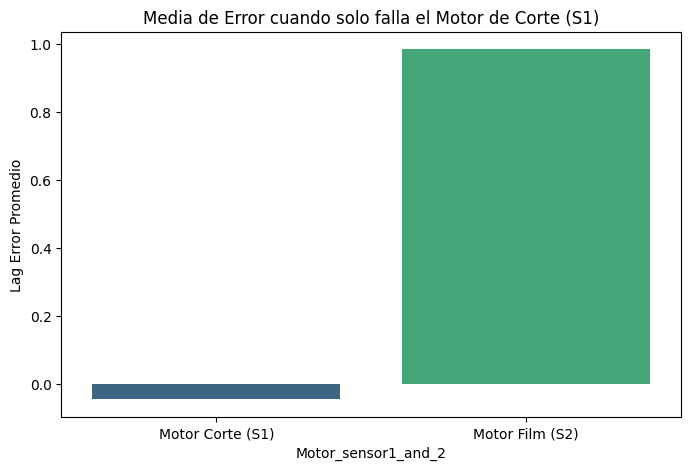

In [5]:
# 2. Preparamos los datos para Seaborn (necesitamos un formato largo)
# Creamos un mini dataframe para la gráfica
# df_caso3= df1_copia[(df1_copia['s1'] == 1) & (df1_copia['s2'] == 0)]

# https://cursos.kobalto.es/teoria/pandas-advanced#method=reset_index

data_plot = df_caso3[['pCut::CTRL_Position_controller::Lag_error', 
                    'pSvolFilm::CTRL_Position_controller::Lag_error']].mean().reset_index()
data_plot.columns = ['Motor_sensor1_and_2', 'Error_Medio']

# 3. Dibujamos siguiendo un barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=data_plot, x='Motor_sensor1_and_2', y='Error_Medio', palette='viridis')

plt.title('Media de Error cuando solo falla el Motor de Corte (S1)')
plt.ylabel('Lag Error Promedio')
plt.xticks([0, 1], ['Motor Corte (S1)', 'Motor Film (S2)'])
plt.show()

## PCA Y PREPROCESAMIENTO PARA EL PUNTO 5

In [6]:
# transformemos mode de categórico a numérico con ordinalencoder
X = df1_copia.drop('averia', axis=1)
X = X.drop('s1', axis=1)
X = X.drop('s2', axis=1)

X1 = np.array(df1_copia[['mode']])

# Definir el orden explícitamente
encoder = OrdinalEncoder(
    categories=[['mode0', 'mode1', 'mode2', 'mode3', 'mode4', 'mode5', 'mode6', 'mode7', 'mode8']] 
)
X['mode'] = encoder.fit_transform(X1)

X

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,1.0
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,1.0
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,1.0
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,1.0
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.179999,-0.277697,-0.023948,194924473,7220.077148,11693928,4610.663086,0.958136,1499.999756,12,28,185909.0,518.0,2.0
1062908,8.183999,-0.285098,-0.022138,194924502,7257.842773,11693946,4618.213379,0.971821,1499.999756,12,28,185909.0,518.0,2.0
1062909,8.187999,-0.155192,-0.034412,194924531,7371.139160,11693964,4582.979004,0.981734,1499.999756,12,28,185909.0,518.0,2.0
1062910,8.191999,-0.371426,0.031594,194924560,7360.839844,11693983,4615.696777,0.987367,1499.999756,12,28,185909.0,518.0,2.0


In [8]:
# StandarScaler
#variable de columnas a borrar
columnas_borrar= ['mode', 's1', 's2', 'averia']

# 2. Aplicamos el drop
X_limpio = df1_copia.drop(columns=columnas_borrar)

# 3. Ahora sí, escalamos las columnas puras (X_limpio)
# Aplicar Z-Score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_limpio)

print("Z-Score (Estandarización):")
print(X_scaled)



Z-Score (Estandarización):
[[-1.73123454  0.52681709  0.22666671 ... -1.47681187  1.48699532
  -1.72871268]
 [-1.72954308  0.66174939  0.02109662 ... -1.47681187  1.48699532
  -1.72871268]
 [-1.72785163  0.77310668 -0.14875354 ... -1.47681187  1.48699532
  -1.72871268]
 ...
 [ 1.72779296 -0.05685188 -0.28344355 ...  1.35056235  1.54159494
   1.7304017 ]
 [ 1.72948442 -0.41257436  0.26110211 ...  1.35056235  1.54159494
   1.7304017 ]
 [ 1.73117587 -0.26880049  0.08441963 ...  1.35056235  1.54159494
   1.7304017 ]]


##PCA

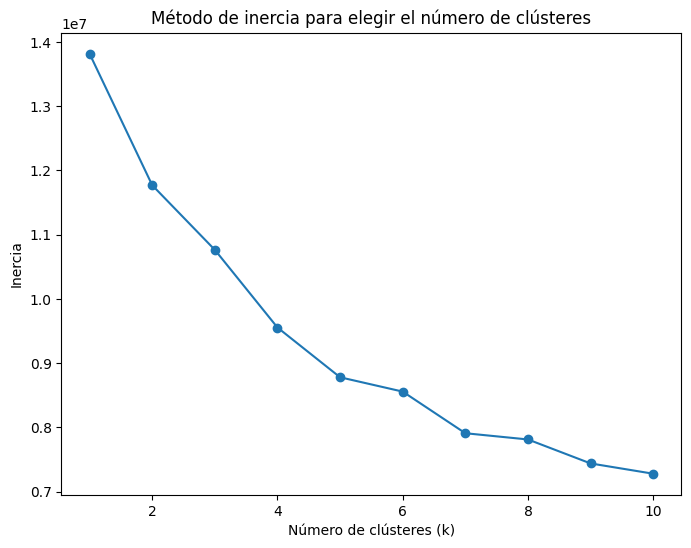

In [ ]:
# 3. Método de búsqueda inercia: Determinar el número óptimo de clústeres
inertia = []  # Guardaremos la inercia para diferentes valores de k (número de clústeres)
for k in range(1, 11):  # Probar para k = 1 hasta k = 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar la inercia para cada k (Método del Codo)
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método de inercia para elegir el número de clústeres')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.show()


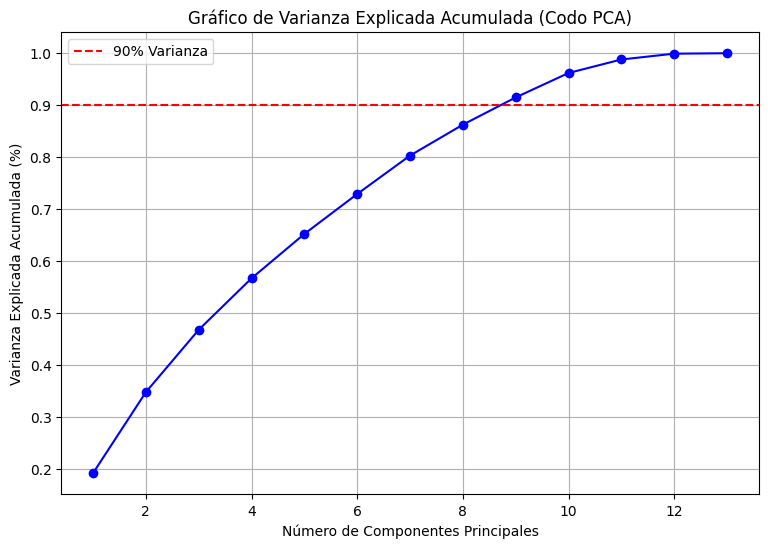

In [ ]:
# Búsqueda del codo:

# 1. Se configura el PCA (sin límite de componentes para verlos todos)
pca = PCA()
pca.fit(X_scaled)  

# 2. Calculamos la varianza acumulada. cumsum= Suma acumulativa. Cada elemento es la suma de todos los anteriores.
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# 3. Graficamos el codo (DEBE SER ASCENDENTE!!!)
plt.figure(figsize=(9, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza') # Referencia del 90%
plt.title('Gráfico de Varianza Acumulada (Codo PCA)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada (%)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
"""
# === PASO 2: Matriz de covarianza ===
# Describe cómo varían conjuntamente las variables.
# Diagonal = varianzas; resto = covarianzas entre pares.
n = X_scaled.shape[0]
cov_matrix = (X_scaled.T @ X_scaled) / (n - 1)
# Equivalente: cov_matrix = np.cov(X_scaled, rowvar=False)

# === PASO 3: Autovalores y autovectores ===
# La descomposición espectral da las direcciones principales
# (autovectores) y cuánta varianza captura cada una (autovalores).
# Usamos eigh porque la covarianza es simétrica: más rápido y
# numéricamente más estable que eig, y garantiza autovalores reales.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Ordenar de mayor a menor (eigh devuelve ascendente)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Varianza explicada en proporción
ratio = eigenvalues / eigenvalues.sum()
print("Proporción de varianza explicada:", ratio.round(3))
print("Acumulada:", np.cumsum(ratio).round(3))

# === PASO 4: Proyección ===
# Seleccionamos los k autovectores con mayor autovalor y proyectamos
# los datos centrados sobre la matriz W formada por esos autovectores.
k = 2
W = eigenvectors[:, :k]   # forma (4, 2)
X_pca = X_scaled @ W       # forma (100, 2)

print("Forma original:", X_scaled.shape)
print("Forma reducida:", X_pca.shape)
print("Varianza conservada:", ratio[:k].sum().round(3))

# === Comparativa con sklearn ===
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

# Pueden diferir en signo (ambos válidos), pero magnitudes idénticas
print("Diferencia con sklearn:",
    np.abs(np.abs(X_pca) - np.abs(X_pca_sklearn)).max())
"""

In [ ]:
# primero primerísimo vamos a mostrar X

